# Importing OpenCV
Making sure it's properly installed

In [1]:
import cv2

cv2.__version__

'4.6.0'

# Reading image from disk
The image is stored as a numpy array with shape = (height, width, channels=3). The channels order is BGR (blue, green, red). 

In [2]:
img = cv2.imread('data/00-puppy.jpg')
type(img)

numpy.ndarray

In [3]:
img.shape

(1300, 1950, 3)

# Displaying image using matplotlib
By default, matplotlib assumes the image is RGB. However, OpenCV uses BGR format. For this reason, the red and blue are swapped.

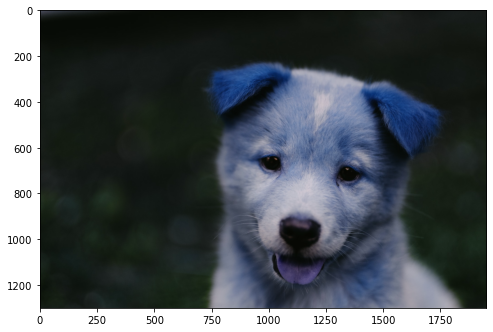

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.show()

# Converting from BGR to RGB
To display colors correctly using matplotlib, we need to convert the image to RGB

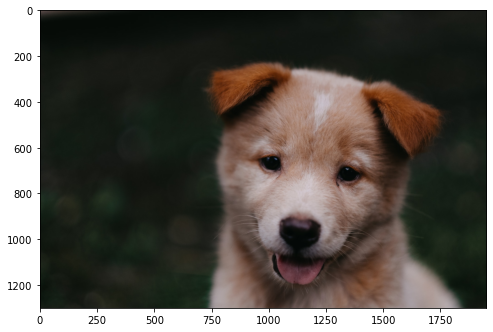

In [5]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.show()

# Converting BGR to Gray
In many cases we need to work with a grayscale image. Grayscale images are 2D with shape = (height, width). If we use `plt.imshow` to display a gray image, we need to specify `cmap='gray'`.

(1300, 1950)


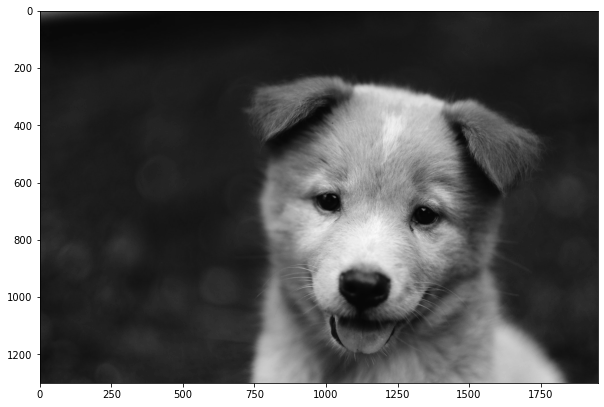

In [9]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(img_gray.shape)

plt.figure(figsize=(10, 10))
plt.imshow(img_gray, cmap='gray')
plt.show()

# Resizing image

To resize the image to a fixed size:

(200, 200, 3)


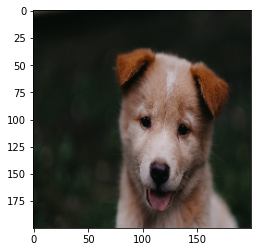

In [11]:
img_smaller = cv2.resize(img_rgb, (200, 200))
print(img_smaller.shape)

plt.imshow(img_smaller)
plt.show()

To Keep aspect ratio (for example to make the image 50% of original size)

(650, 975, 3)


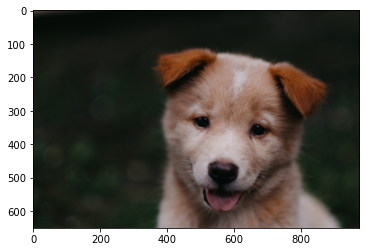

In [12]:
img_smaller2 = cv2.resize(img_rgb, (0, 0), fx=0.5, fy=0.5)
print(img_smaller2.shape)

plt.imshow(img_smaller2)
plt.show()

# Edge detection
## method 1: Sobel operators

In [22]:
# helper function to display gray images
def imshow(img):
    plt.figure(figsize=(10, 10))
    plt.imshow(img, cmap='gray')
    plt.show()

Original image (gray):

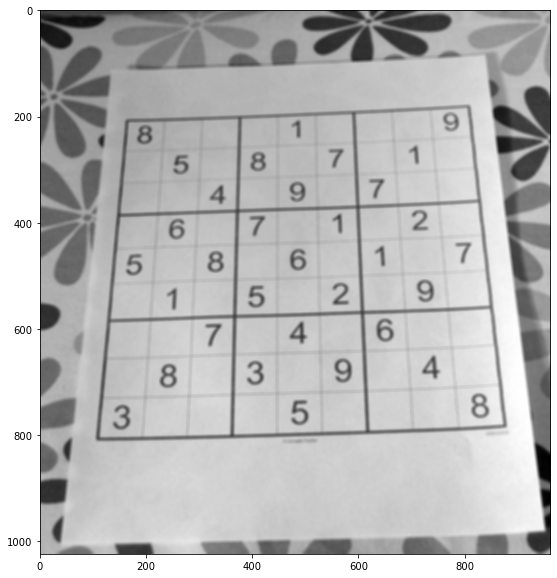

In [30]:
img = cv2.imread('data/sudoku.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# blurring image to reduce noise
# try to comment this line and see the difference
# also try to change ksize
img_gray = cv2.blur(img_gray, ksize=(7,7)) 

imshow(img_gray)

Sobel x gradient (vertical edges):

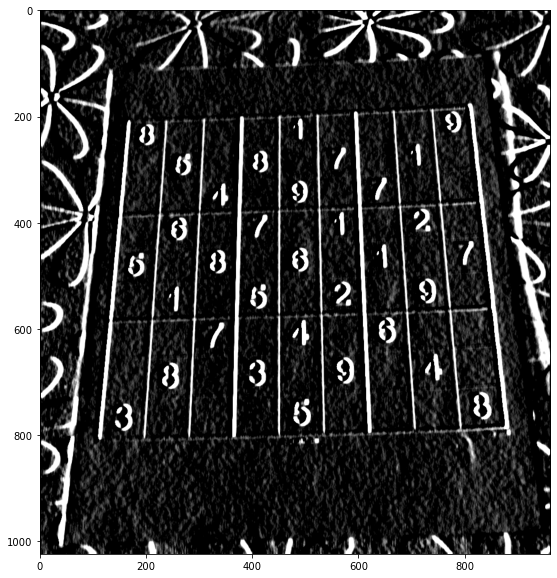

In [31]:
img_sobel_x = cv2.Sobel(img_gray, cv2.CV_8U, dx=1, dy=0, ksize=5)
imshow(img_sobel_x)

Sobel y gradient (horizontal edges):

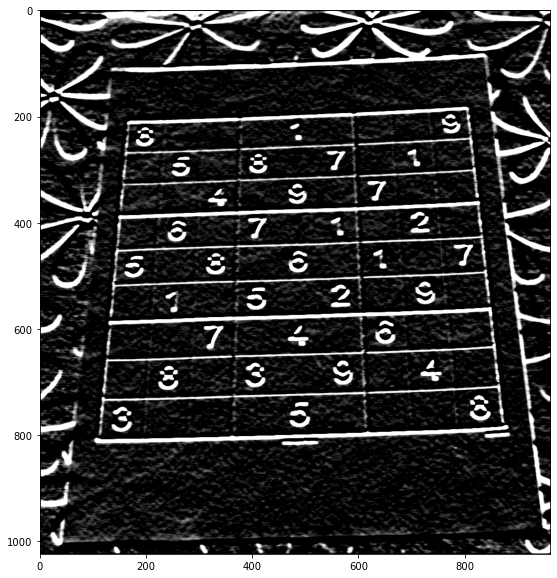

In [32]:
img_sobel_y = cv2.Sobel(img_gray, cv2.CV_8U, dx=0, dy=1, ksize=5)
imshow(img_sobel_y)

Combining both x and y

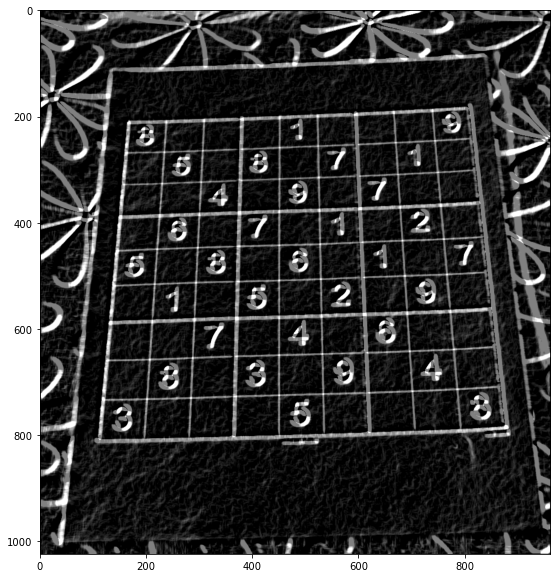

In [33]:
img_sobel = cv2.addWeighted(src1=img_sobel_x, alpha=0.5, src2=img_sobel_y, beta=0.5, gamma=0.0)
imshow(img_sobel)

## method 2: Laplacian

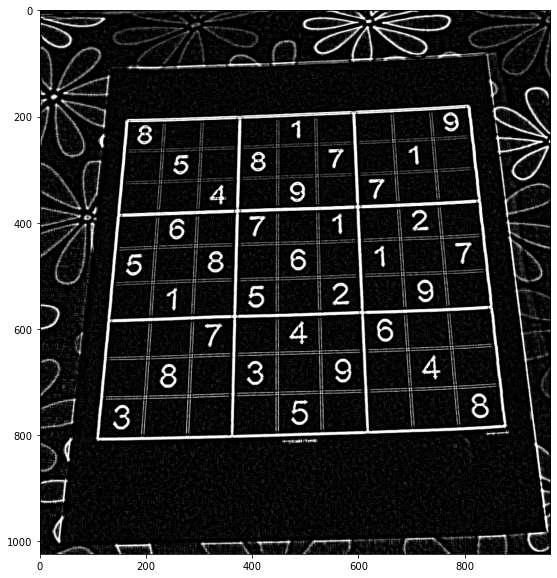

In [34]:
img_laplacian = cv2.Laplacian(img_gray, cv2.CV_8U, ksize=5)
plt.figure(figsize=(10, 10))
plt.imshow(img_laplacian, cmap='gray')

# method 3: Canny

Canny does use two thresholds (upper and lower):
- If a pixel gradient is higher than the upper threshold, the pixel is accepted as an edge
- If a pixel gradient value is below the lower threshold, then it is rejected.
- If the pixel gradient is between the two thresholds, then it will be accepted only if it is connected to a pixel that is above the upper threshold.

Source: https://docs.opencv.org/3.4/da/d5c/tutorial_canny_detector.html 

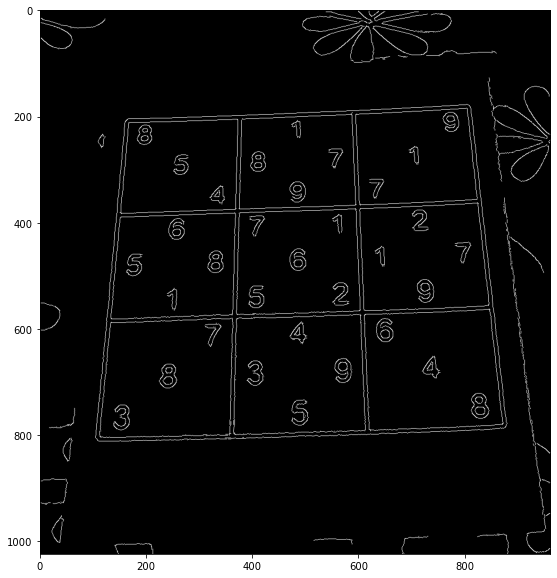

In [35]:
img_canny = cv2.Canny(img_gray, threshold1=0, threshold2=127)
imshow(img_canny)

# Thresholding (segmentation)

## method 1: binary

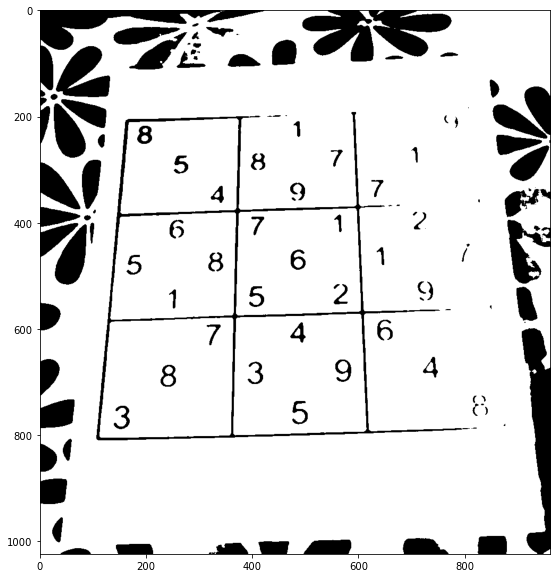

In [36]:
ret, img_bin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
imshow(img_bin)

## method 2: Otsu

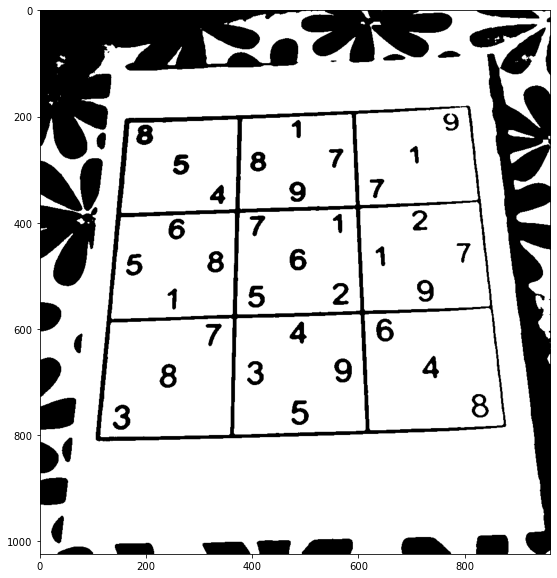

In [37]:
ret, img_otsu = cv2.threshold(img_gray, 127, 255, cv2.THRESH_OTSU)
imshow(img_otsu)

# Inverting colors

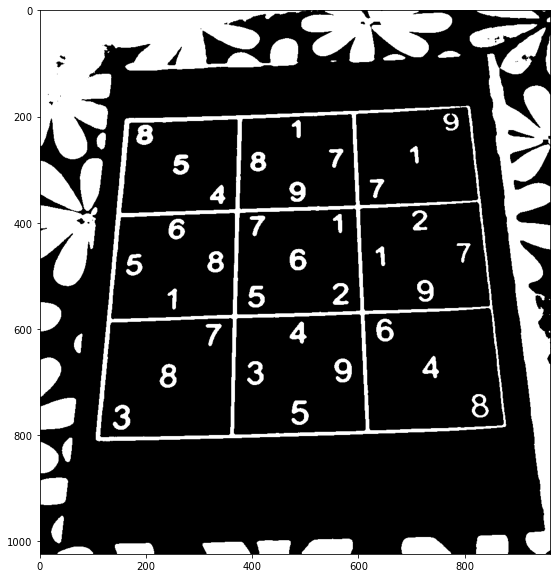

In [38]:
img_invert = 255 - img_otsu
imshow(img_invert)